# Analytical model of a single-cylinder diesel engine

This document will review and attempt to recreate the analytical engine model developed by Zweiri et al. [[1]](#zweiri2001).

## 2 ENGINE AND DYNAMOMETER DYNAMIC MODEL

The engine crank shaft angle is denoted $\theta_1$, and is considered independent.
The dynamometer crank shaft angle is denoted $\theta_2$.

The variable transformation from time domain to crank angle domain is then:
$$
\dot{\theta}_1 = \frac{d\theta_1}{dt} = \omega_1(\theta_1) \tag{1}
$$
$$
\ddot{\theta}_1 = \omega_1 \frac{d\omega_1}{d\theta_1} \tag{2}
$$
$$
\dot{\theta}_2 = \omega_1 \frac{d\theta_2}{d\theta_1} = \omega_2(\theta_1) \tag{3}
$$
$$
\ddot{\theta}_2 = \frac{d\omega_2}{dt} = \omega_1 \frac{d\omega_2}{d\theta_1} \tag{4}
$$

From equation (3), the relationship between the dynamometer angular position $\theta_2$ and the independent variable $\theta_1$ is given by:

$$
\int_0^{\theta_2} d\theta_2 = \int_0^{\theta_1} \frac{\omega_2(\theta_1)}{\omega_1(\theta_1)} d\theta_1 \hspace{0.1cm} \Rightarrow \hspace{0.1cm} \theta_2 = \int_0^{\theta_1} \frac{\omega_2(\theta_1)}{\omega_1(\theta_1)} d\theta_1 \tag{5}
$$

The following two equations, derived from Lagrangian principles, describe the dynamics of the system in the crank angle domain:
$$
\dot{\omega}_1 = \frac{1}{\tau \omega_1} \left\{ T_i(\theta_1) - \left[ M r G(\theta_1) G_1(\theta_1) + \frac{1}{2} \frac{\partial J(\theta_1)}{\partial \theta_1} \right] \omega_1^2 - \sum_{k=1}^{5} T_{fk} - T_S - T_D \right\} \tag{6}
$$
$$
\dot{\omega}_2 = \frac{1}{J_1 \omega_1} (T_D + T_S - T_L) \tag{7}
$$
where the moment of inertia of the crankshaft assembly and the reciprocating parts, $\tau$, is given by $\tau = J(\theta_1) + M r G(\theta_1) G_2(\theta_1)$.

The indicated engine torque, $T_i$, is generated by the conversion of energy from chemical to thermal to mechanical, during the combustion process.

The relationship between the indicated gas pressure, $P_i$, and the indicated torque, $T_i$, is deterministic and is a function of engine geometry. This relationship is given by:
$$
T_i = (P_i - P_{atm}) A_p r G(\theta_1) \tag{8}
$$
where
$$
G(\theta_1) = \frac{\sin(\theta_1 + \beta)}{\cos(\beta)} = \sin(\theta_1) + \sqrt{ \frac{1 - \lambda(\theta_1)}{\lambda(\theta_1)} } \cos(\theta_1) \tag{9}
$$
and $\lambda(\theta_1)$ is a geometric function given by
$$
\lambda(\theta_1) = 1 - \left[ \frac{\delta + r \sin(\theta_1 - \phi)}{L} \right]^2 \tag{10}
$$
where $\beta$ is the angle of the connecting rod, $r$ is the crank radius (equal to half of the stroke), $L$ is the connecting rod length, $\delta$ is the piston pin offset and $\phi$ is the connecting rod angle when the piston is at the top dead centre position.

From the piston-crank geometry, the piston displacement, $y$, is given by:
$$
y = \sqrt{(r + L)^2 - \delta^2} - \left[ L \cos(\beta) + r \cos(\theta_1 - \phi) \right] \tag{11}
$$
where the angles $\phi$ and $\beta$ are given by:
$$
\phi = \sin^{-1} \left( \frac{ \delta }{ r + L } \right) \hspace{0.3cm} \mathrm{and} \hspace{0.3cm} \beta = \sin^{-1} \left( \frac{ \delta + r \sin(\theta_1 - \phi) }{ L } \right) \tag{12}
$$

The reciprocating torque, $T_r$, is produced by the motion of the piston assembly and the small end of the connecting rod.

It is given by:
$$
T_r = M r G(\theta_1) \ddot{y} = M r G(\theta_1) \left[ G_1(\theta_1) \dot{\theta_1^2} + G_2(\theta_1) \ddot{\theta_1} \right] \tag{13}
$$
where $G_1(\theta_1)$ and $G_2(\theta_1)$ are functions of the engine geometry:

$$
G_1(\theta_1) = r \left\{ \cos(\theta_1 - \phi) \left[ 1 + \frac{ (r / L) \cos(\theta_1 - \phi) }{ \sqrt{ \lambda(\theta_1)^3 } } \right] - \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \sin(\theta_1 - \phi) \right\} \tag{14}
$$

$$
G_2(\theta_1) = r \left[ \sin(\theta_1 - \phi) + \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \cos(\theta_1 - \phi) \right] = r G(\theta_1 - \phi) \tag{15}
$$

$M$ is the mass of piston rings, pin and the small end of the connecting rod and $\ddot{y}$ is the acceleration of the reciprocating components.

The torsional stiffness torque, $T_s$, and damping torque, $T_D$, at the coupling between the engine and the dynamometer, are given by:
$$
T_S = S(\theta_1 - \theta_2) \tag{16}
$$
$$
T_D = D(\dot{\theta_1} - \dot{\theta_2}) \tag{17}
$$
where $S$ and $D$ are stiffness and damping coefficients.

### 2.1 Friction model

The friction torque terms include:
- piston assembly friction, $T_{f1}$
- bearing friction torque, $T_{f2}$
- valve train friction torque, $T_{f3}$
- pumping losses torque, $T_{f4}$
- pumps losses torque, $T_{f5}$

These are subtracted from the instantaneous indicated torque to produce the brake torque at the shaft.

Subsequently, the resistance torque $\sum_{j=1}^{n} T_{Lj}$, which is the result of external loading by the dynamometer, is subtracted from the brake torque and the net value is passed on to the engine dynamic model.

#### *2.1.1 Ring friction torques*

The ring assembly friction torque can be expressed as:
$$
T_{f1} = \eta \hspace{1mm} r \hspace{1mm} |G(\theta_1)| \left\{ \sum_{ii=1}^{N} \left[ \frac{ E_{ii} g }{ 7.07 d_r (d_r / B_{ii} - 1)^3 } \right] \pi d_r B_{ii} + \sum_{ii=1}^{N} a_{ii} |p_i - p_{atm}| \pi d_r B_{ii} + \frac{ |p_i - p_{atm}| (\pi/4) d^2 - M G_1(\theta_1) \dot{\theta_1^2} }{ \eta + G_3(\theta_1) } \right\} \tag{18}
$$
where
$$
G_3(\theta_1) = \frac{ L \sqrt{ 1 - \left\{ \left[ \delta + r \sin(\theta_1 - \phi) \right] / L \right\}^2 } }{ \delta + r |\sin(\theta_1 - \phi)| } \tag{19}
$$

The coefficient of friction for hydrodynamic lubrication, $\eta$, is directly proportional to the piston speed and oil viscosity and inversely proportional to the ring load.
Thus:
$$
\eta =
\begin{cases}
    c_1 - (c_1 - z) |\sin(\theta_1)| \hspace{0.2cm} , \hspace{0.2cm} \text{for} \hspace{0.2cm} 1.5 \pi \leq \theta_1 \leq 2.5 \pi \\
    z \hspace{4cm} , \hspace{0.2cm} \text{otherwise}
\end{cases} \tag{20}
$$
where $z$ is the hydrodynamic friction coefficient given by
$$
z = \sqrt{ \frac{ \mu \dot{\theta_1} r |G(\theta_1)| }{ L_r } } \tag{21}
$$
and $L_r$ is the load per unit length given by
$$
L_r = \sum_{ii=1}^{N} \left[ \frac{ E_{ii} g }{7.07 d_r ( d_r / B_{ii} - 1 )^3 } + |p_i - p_{atm}| \right] B_{ii} \tag{22}
$$

#### *2.1.2 Skirft friction torque*

The piston skirt friction is derived by applying Newton's law for viscous friction and can be expressed as
$$
T_{f2} = \left[ \frac{ \mu \dot{\theta_1} r G(\theta_1) }{ O_c } \right] d L_s r G(\theta_1) \tag{23}
$$

#### *2.1.3 Bearings friction torque*

The bearings generally operate in the hydrodynamic lubraction mode except around top dead centre. By solving the Reynolds equation, the instantaneous friction torque during hydrodynamic lubrication mode, for $0 \leq \theta_1 < 1.9\pi$ and $2.4\pi < \theta_1 \leq 4\pi$, on the journal bearing is given by
$$
T_{f3} = \frac{ F_t \epsilon }{ 2 } + \frac{ 2 \pi \mu \dot{\theta_1} r_b^3 L_b G_4(\theta_1) }{ \sqrt{ (c_r^2 - \epsilon^2) } } \tag{24}
$$
where the geometrical function $G_4(\theta_1)$ is given as
$$
G_4(\theta_1) = 1 + \frac{ \cos(\theta_1) }{ \sqrt{ (L / r)^2 - \sin(\theta_1^2) } } \tag{25}
$$

The friction coefficient for the lubrication mode, $\eta_{bm}$, depends on the properties of the pair of rubbing materials. $\eta_{bm}$ has a negative slope in the Stribeck diagram and is given by:
$$
\eta_{bm} = c_2 \left( \frac{ \mu \dot{\theta_1} }{ |p_i - p_{atm}| } \right)^{-n} \tag{26}
$$
where the index number $n$ is taken as $\frac{1}{3}$.

The proposed formula to calculate the bearing friction torque around the top dead centre,
for $1.9\pi \leq \theta_1 \leq 2.4\pi$, is
$$
T_{f4} = \eta_{bm} r_b \times \left\{ \frac{ (\pi/4) d^2 |p_i - p_{atm}| - r \dot{\theta_1^2} M [\cos(\theta_1 + (r / L) \cos(2 \theta_1) }{ G_5(\theta_1) } \times |\cos(-2 \theta_1 + 4.3\pi)| \right\} \tag{27}
$$
where $G_5(\theta_1)$ is given by
$$
G_5(\theta_1) = \sqrt{ 1 - \left[ \frac{ \delta + r \sin(\theta_1 - \phi) }{ L } \right]^2 } \tag{28}
$$
and $|\cos(-2 \theta_1 + 4.3\pi)|$ is an empirical term to take into account the behaviour of the mixed friction torque around top dead centre.

#### *2.1.4 Valve train friction torque*

The valve train friction torque is formulated to depend on the load and the engine speed, and is given by:
$$
T_{f5} = \left( \frac{ d_i^4 G_v }{ 8 d_o^3 N_t} \right) V_1 N_v ( 1 - c_3 \dot{\theta_1} ) r |G(\theta_1)| \tag{29}
$$

#### *2.1.5 Auxiliaries and gears torque losses*

This component models the friction due to the unloaded journal bearings, water pump, fuel pump, oil pump, generator and gears. A hydrodynamic lubrication mode is assumed, and the friction coefficient is calculated as in equation (21), with unit oil-film pressure.

If the terms of the auxiliaries are assumed to be unity, then the friction torque for auxiliaries is formulated as:
$$
T_{f6} = \sqrt{ \mu \dot{\theta_1} } \tag{30}
$$

#### *2.1.6 Viscosity variations with temperature*

Oil viscosity decreases with increasing temperature, and thus affects the engine friction calculations. Furthermore, the viscosity increases with pressure.

The oil viscosity as a function of temperature and pressure for SAE 30 oil is determined by a non-linear least-squares method for exponential function, and is given by:
$$
\mu = 7.849 \times 10^{-5} \times \exp \left( \frac{ -8.670 \times 10^{-3} T^2 - 1.115311 T + 1361 }{ T + 133 } + \frac{ p }{ 105 } \right) \tag{31}
$$

In this study, only the effects of temperature variations are taken into consideration, because oil pressure has only a minor effect on the engine oil viscosity, and hence $p = p_{atm}$ is used in equation (31).

### 2.2 Inertia variation

The crank angle varying inertia of an engine crank shaft assembly is given by:
$$
\begin{align*}
J(\theta_1) = \ & J_c + m_c ( b_2 r )^2 + J_R \left[ \left( \frac{ r }{ L } \right)^2 \frac{ 1 }{ \lambda(\theta_1) } \cos^2(\theta_1) \right] + m_p r^2 \left[ \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \cos(\theta_1) + \sin(\theta_1) \right]^2 \\
            &+ m_R r^2 ( 1 - b_1 )^2 \cos^2(\theta_1) + m_R r^2 \left[ b_1 \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \cos(\theta_1) + \sin(\theta_1) \right]^2 \tag{32}
\end{align*}
$$
and
$$
\begin{align*}
\frac{ \partial J(\theta_1) }{ \partial \theta_1 } = \ & 2 J_R \left[ \left( \frac{ r }{ L } \right)^3 \frac{ \sqrt{ 1 - \lambda(\theta_1) } }{ \lambda(\theta_1)^2 } \cos^3(\theta_1) - \left( \frac{ r }{ L } \right)^2 \frac{ 1 }{ \lambda(\theta_1) } \cos(\theta_1) \sin(\theta_1) \right] - 2 m_R ( 1 - b_1 )^2 r^2 \cos(\theta_1) \sin(\theta_1) \\
& - m_R r^2
\left[ b_1 \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \cos(\theta_1) - \sin(\theta_1) \right] \left\{ - \left[ \frac{ r b_1 }{ L \sqrt{ \lambda(\theta_1)^3 } } \right] \cos^2(\theta_1) - \cos(\theta_1) + b1 \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \sin(\theta_1) \right\} \\
& - m_p r^2 \left[ \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \cos(\theta_1) + \sin(\theta_1) \right] \left\{  \left[ \frac{ r }{ L \sqrt{ \lambda(\theta_1)^3 } } \right] \cos^2(\theta_1) - \cos(\theta_1) + \sqrt{ \frac{ 1 - \lambda(\theta_1) }{ \lambda(\theta_1) } } \sin(\theta_1) \right\} \tag{33}
\end{align*}
$$
where $J_c$ is the moment of inertia of the crankshaft, $J_R$ is the moment of inertia of the connecting rod, $m_c$ is the mass of the crankshaft, $m_R$ is the mass of the connecting rod, $m_p$ is the mass of the piston, $b_1$ is the length ratio of CB to CA, and $b_2$ is the length ratio of ED to DC as shown below in Figure 2.

<div style="text-align: center;">
  <img src="fig_2.png" width="400"/>
</div>

### 2.3 Cylinder volume and area

From the piston-crank mechanism, the cylinder volume is
$$
V = \frac{ V_d } { c - 1 } + \frac{ \pi d^2 }{ 4 } \left[ \sqrt{ ( r + L )^2 - \delta^2 } - \left\{ \sqrt{ L^2 - [ \delta + r \sin(\theta_1 - \phi) ]^2 } + r \cos(\theta_1 - \phi) \right\} \right] \tag{34}
$$

The cylinder heat transfer area is given by
$$
A = \alpha \frac{ \pi d^2 }{ 4 } + \pi d \left[ \sqrt{ ( r + L )^2 - \delta^2 } - \left\{ \sqrt{ L^2 - [ \delta + r \sin(\theta_1 - \phi) ]^2 } + r \cos(\theta_1 - \phi) \right\} \right] \tag{35}
$$
where $\alpha > 2$ for a non-flat piston and cylinder head, and $\alpha = 2$ for a flat piston top and cylinder heat bottom.

The cylinder volume derivative is
$$
\dot{V} = \frac{ \pi d^2 }{ 4 } r \left\{ \sin(\theta_1 - \phi) + \frac{ \cos(\theta_1 - \phi) [ \delta + r \sin(\theta_1 - \phi) ] }{ \sqrt{ L^2 - [ \delta + r \sin(\theta_1 - \phi) ]^2 } } \right\} \tag{36}
$$

## 3 THERMODYNAMIC MODELLING

### 3.1 Conservation of mass and energy

Using the first law of thermodynamics for an open system and the ideal gas law, the temperature differential for each control volume can be written as:
$$
T^\prime = \frac{ \left( \sum_j Q^\prime_{\text{ht}j} + \sum_{\text{in}} h_{0\text{in}} m^\prime_{\text{in}} - \sum_{\text{out}} h_{0\text{out}} m^\prime_{\text{out}} + m^\prime_{\text{bf}} h_{\text{for}} - u m^\prime \right) (1/m) - (RT/V) V^\prime - (\partial{u}/\partial{F}) \dot{F} } { \partial{u}/\partial{T} } \tag{37}
$$
where subscript $j$ denotes surfaces with different rates of heat transfer, subscripts "in" and "out" denote input to and output from a control volume, $F$ is the equivalence ratio, $m_{\text{bf}}$ is the burned fuel mass, $Q_{\text{ht}}$ is the heat transfer, $R$ is the gas constant, $h_0$ is the stagnation enthalpy, hence implicitly accounting for kinetic energy, $h_{\text{for}}$ is the enthalpy of formation of the hydrocarbon, $u$ is the specific internal energy, and $P, T, V$ and $m$ are the pressure, temperature, volume and mass of the control volume.

The internal energy is assumed to be a function of the temperature and equivalence ratio:
$$
u = u(T,F) \tag{38}
$$

The gas constant $R$ is given by
$$
R = \frac{0.278 + 0.02F}{1 + f_{\text{s}} F} \tag{39}
$$
where $f_s$ is the stoichiometric fuel-air ratio.

Considering mass conservation for both air and fuel gives
$$
m^\prime = \sum_{\text{in}} m^\prime - \sum_{\text{out}} m^\prime + \sum m^\prime_{\text{bf}} \tag{40}
$$

Total mass:
$$
m = m_{\text{a}} + m_{\text{bf}} \tag{41}
$$

Fuel-air equivalence ratio:
$$
F = \frac{f}{f_s} \tag{42}
$$
where $f$ is the fuel-air ratio.

The term for $F^\prime$ in equation (37) is given by:
$$
F^\prime = \left( \frac{1 + f_{\text{s}} F}{m} \right) \left( \frac{1 + f_{\text{s}} F}{f_{\text{s}}} m^\prime_{\text{bf}} - F m^\prime \right) \tag{43}
$$

### 3.2 Ports and valves mass flowrates

The mass flowrate through a valve has the form
$$
m^\prime = C_{\text{d}} A_{\text{v}} P_{\text{u}} \sqrt{ \frac{2\gamma}{\gamma-1} \frac{1}{RT_{\text{u}}} \left[ \left( \frac{P_{\text{d}}}{P_{\text{u}}} \right)^{2/\gamma} - \left( \frac{P_{\text{d}}}{P_{\text{u}}} \right)^{(\gamma+1)/\gamma} \right] } \tag{44}
$$
where $C_{\text{d}}$ is discharge coefficient, $\gamma$ is the specific heat ratio and $A_{\text{v}}$ is the valve or port area.

For sonic flow $P_{\text{d}}/P_{\text{u}} \leq [2\gamma / (\gamma+1)]^{\gamma/(\gamma-1)}$, the mass flowrate becomes
$$
m^\prime = C_{\text{d}} A_{\text{v}} P_{\text{u}} \sqrt{ \frac{\gamma}{RT} \left( \frac{2}{\gamma+1} \right)^{(\gamma+1)/(\gamma-1)} } \tag{45}
$$

### 3.3 Combustion

A single-zone model is used to predict both premixed and diffusion burning. The ignition delay (ID) equations as a function of cylinder pressure and temperature can be used to calculate the start of the combustion:
$$
ID = 3.45 \left( \frac{P}{101.3} \right)^{-1.02} \text{e}^{2100/T} \tag{46}
$$
with the constraint
$$
\int_{\theta_{1,\text{inj}}}^{\theta_{1,\text{ign}}} \frac{d\theta_1}{ID} = 1 \tag{47}
$$
where $\theta_{1,\text{inj}}$ is the angle at injection and $\theta_{1,\text{ign}}$is the angle at ignition.

The normalized premixed burning rate is given by
$$
m^\prime_{\text{fpre}} = k_{\text{p1}} \cdot k_{\text{p2}}  \cdot \theta^{k_{\text{p1}}-1}_{1\text{norm}} \cdot (1 - \theta^{k_{\text{p1}}-1}_{1\text{norm}})^{k_{\text{p2}}-1} \tag{48}
$$

The normalized diffusion burning rate is given by
$$
m^\prime_{\text{fdiff}} = k_{\text{d1}} \cdot k_{\text{d2}} \cdot \theta^{k_{\text{d1}}-1}_{1\text{norm}} \cdot \exp(-k_{\text{d1}} \cdot \theta^{k_{\text{d2}}}_{1\text{norm}} ) \tag{49}
$$

Values of the constants are taken from the N. Watson article [9] referenced in Zweiri:
$$
k_{\text{p1}} = 2.0 + 1.25 \times 10^{-8} ( ID \times N)^{2.4}
$$
$$
k_{\text{p2}} = 5000.0
$$
$$
k_{\text{d1}} = 14.2/F^{0.644}
$$
$$
k_{\text{d2}} = 0.79 \times k_{\text{d1}}^{0.25}
$$
where $N$ is engine speed in RPM.

The fraction of the total fuel that goes to the premixed burning, $f_{\text{t}}$m is given by
$$
f_{\text{t}} = 1 - 0.926 F^{0.37} ID^{-0.26} \tag{50}
$$

Assuming complete combustion in 125$^\circ$ of crank angles (combustion duration), the normalized angle is defined as
$$
\theta_{1\text{norm}} = \frac{\theta_1 - \theta_{1,\text{ign}}}{125} \tag{51}
$$

Finally, the fuel burning rate is given by
$$
m^\prime_{\text{fnorm}} = f_{\text{t}} m^\prime_{\text{fpre}} + (1-f_{\text{t}}) m^\prime_{\text{fdiff}} \tag{52}
$$
$$
m^\prime_{\text{bf}} = \frac{ m_{\text{f}} m^\prime_{\text{fnorm}} }{\theta_{1\text{com}}} \tag{53}
$$
where $\theta_{1\text{com}}$ is the combustion period in degrees.

### 3.4 Cylinder heat transfer

Instantaneous convective heat transfer:
$$
Q^\prime_{\text{ht1}} = h_{\text{con}} A_{\text{v}} (T-T_{\text{wall}}) \tag{54}
$$

where $h_{\text{con}}$ is the heat transfer coefficient based on forced convection and is given by
$$
h_{\text{con}} = 130 V^{-0.06} P^{0.8} T^{-0.4}(N_{\text{p}} + 1.4)^{0.8} \tag{55}
$$
where $N_{\text{p}}$ is mean piston speed.

Instantaneous radiant heat transfer:
$$
Q^\prime_{\text{ht2}} = \varepsilon \sigma A_{\text{v}} (T^4_{\text{rad}} - T^4_{\text{wall}}) \tag{56}
$$
where $\varepsilon$ is apparent grey body emissivity, $\sigma$ is the Stephan-Boltzman constant, and $T_{\text{rad}}$ is apparent radiant temperature.

Radiant temperature $T_{\text{rad}}$ is calculated as the mean of adiabatic flame temperature and average bulk gas temperature:
$$
T_{\text{rad}} = \frac{T + T_{F=1.1}}{2} \tag{57}
$$
where $T_{F=1.1}$ is the temperature of the combustion products when fuel-air ratio is slightly greater than stoichiometric ($F=1.1$).

$T_{F=1.1}$ is computed from a correlation of instantaneous air temperature and pressure:
$$
T_{F=1.1} = [1 + 0.0002317(T-950)] \times (2726.3 + 0.906P - 0.003233P^2) \tag{58}
$$
for $800 K < T < 1200 K$, and
$$
T_{F=1.1} = [1 + 0.000249(T-650)] \times (2487.3 + 4.7521P - 0.11065P^2 + 0.000898P^3) \tag{59}
$$
for $450 K < T < 800 K$.

The cylinder wall is updated at each step by using a one-dimensional heat conduction model:
$$
Q^\prime_{\text{ht1}} + Q^\prime_{\text{ht2}} = \frac{T_{\text{w}} - T_{\text{coolant}}}{R_{\text{wc}} + R_{\text{w}}} \tag{60}
$$
where $R_{\text{wc}} = 1/h_{\text{coolant}}A$ is the thermal resistance from wall to coolant. Thermal resistance for conduction through the wall is $R_{\text{w}} = t/KA$, where $t$ is wall thickness and $K$ is the thermal conductivity.

A fourth-order polynomial in $T_{\text{m}}$ is obtained and the $i$th solution gives the wall temperature:
$$
\frac{T - T_{\text{wall}}}{R_{\text{gw}}} + \varepsilon \sigma A_{\text{v}} (T^4_{\text{rad}} - T^4_{\text{wall}}) = \frac{T_{\text{w}} - T_{\text{coolant}}}{R_{\text{wc}} + R_{\text{w}}} \tag{61}
$$
where $R_{\text{gw}} = 1/h_{\text{con}}A$ is the thermal resistance from gas to wall.

The cylinder heat release rate can be calculated from equations (54) and (56):
$$
Q^\prime_{\text{ht}} = Q^\prime_{\text{ht1}} + Q^\prime_{\text{ht2}} \tag{62}
$$

### 3.5 Exhaust manifold heat transfer

Heat transfer rate from exhaust gas to manifold is given by
$$
Q^\prime_{\text{ht}} = h_{\text{f}} A_{\text{m}} (T - T_{\text{m}}) \tag{63}
$$

Heat transfer rate from manifold to air:
$$
Q^\prime_{\text{ma}} = h_{\text{n}} A_{\text{m}} (T_{\text{m}} - T_{\text{air}}) \tag{64}
$$

Heat transfer rate due to radiation:
$$
Q^\prime_{\text{r}} = \varepsilon \sigma A_{\text{m}} (T^4_{\text{m}} - T^4_{\text{air}}) \tag{65}
$$

$h_{\text{f}}$ is the forced heat convective coefficient given by
$$
h_{\text{f}} = 0.023 \frac{K}{D_i} R_{\text{e}}^{0.8} P_{\text{r}}^{0.3} \tag{66}
$$
where $R_{\text{e}}$is Reynolds number and $P_{\text{r}}$ is the Prandtl number:
$$
R_{\text{e}} = \frac{\tilde{\omega} D_i}{v} \tag{67}
$$
$$
P_{\text{r}} = \frac{C_p\mu}{K} \tag{68}
$$
where $v$ is the kinematic viscosity, $D_i$ is the inner manifold diameter, $C_p$ is the specific heat and $\tilde{\omega}$ is the average flowrate.

The dynamic viscosity $\mu$ can be calculated as
$$
\mu = \frac{3.3 \times 10^{-7} T^{0.7}}{1 + 0.027F} \tag{69}
$$
The average flowrate $\tilde{\omega}$ is given by
$$
\tilde{\omega} = \frac{NV}{120(\pi D_i^2/4)} \tag{70}
$$
The natural heat convective coefficient $h_{\text{n}}$ is given by
$$
h_{\text{n}} = 0.53 \frac{K}{D_{\text{o}}} (G_{\text{r}} P_{\text{r}})^{0.25} \tag{71}
$$
where $G_{\text{r}}$ is the Grashhof number:
$$
G_{\text{r}} = \frac{ g \zeta (T_{\text{m}} - T_{\text{air}}) (0.9 D_{\text{o}})^3 }{\nu^2} \tag{72}
$$
where $g$ is gravitational acceleration, $D_{\text{o}}$ is the outer manifold diameter, and $\zeta$ is the volumetric coefficient and is set equal to $\zeta = 1/T_{\text{air}}$.

Applying energy conservation to the volume, a non-linear equation in $T_{\text{m}}$ is obtained. The solution gives the manifold temperature which can be substituted into equation (63) to calculate the manifold heat transfer rate:
$$
T_{\text{m}} - T + \frac{D_{\text{o}}}{D_{\text{i}}} \frac{h_{\text{n}}}{h_{\text{f}}} (T_{\text{m}} - T_{\text{air}}) + \frac{D_{\text{o}}}{D_{\text{i}}} \frac{\sigma\varepsilon}{h_{\text{f}}} (T_{\text{m}}^4 - T_{\text{air}}^4) = 0 \tag{73}
$$

# Todo (25.02.2026):
## - need to organize the code snippets so they fit with each other
## - also check reasonable values of all constants

In [25]:

##############################################################################################################
# Imports
##############################################################################################################

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.integrate import solve_ivp, cumulative_trapezoid


In [54]:

##############################################################################################################
# =======================
# Engine parameters dictionary (corrected)
# =======================
params = {
    # Geometry
    'r': 0.05,
    'L': 0.15,
    'delta': 0.002,
    'phi': 0.0,
    'd': 0.08,
    'V_d': np.pi*0.08**2/4*2*0.05,
    'c': 9,
    'alpha': 2,
    'A_p': np.pi*0.08**2/4,
    'b1': 0.4,
    'b2': 0.3,

    # Mass / inertia
    'M': 1.2,
    'm_c': 4.0,
    'm_R': 1.5,
    'm_p': 0.8,
    'J_c': 4.0*0.05**2,
    'J_R': 1/3*1.5*0.15**2,
    'J1': 0.02,

    # Shaft / dynamometer
    'dynamo_load_torque': 0.0,
    'S': 50.0,
    'D': 0.05,

    # Operating conditions
    'P_atm': 101325,
    'RPM': 1000,
    'omega1_0': 100.53,  # rad/s

    # Initial thermodynamic state
    'P0': 101325,
    'T0': 300.0,
    'theta_start': 0.0,
    'R_gas': 287.0,

    # Friction parameters
    'friction_params': friction_params,

    # Combustion / thermal
    'h_for': 44e6,
    'm_fuel': 5e-5,
    'F': 0.95,
    'c_v': 718,
    'Cp_gas': 1005,
    'gamma': 1005/718,

    # Heat release
    'k_p1': 2.0,
    'k_p2': 3000.0,
    'k_d1': 10.0,
    'k_d2': 0.8,
    'ID': np.deg2rad(12),

    # Cylinder / manifold
    'D_i': 0.025,
    'D_o': 0.03,
    'K_gas': 0.03,
    'nu_air': 1.5e-5,
    'mu_gas': 1.8e-5,
    'T_air': 300.0,

    # Heat transfer
    'h_wall': 200.0,
    'T_wall': 450.0,

    # Simulation / kinematics
    'theta1': theta1,
    'omega1': omega1,
    'omega2': omega2,
    'theta2': theta2
}

# Compute initial cylinder mass
V0 = cylinder_volume(params['theta_start'], V_d, c, d, r, L, delta, phi)
params['m0'] = params['P0'] * V0 / (params['R_gas'] * params['T0'])

In [65]:

##############################################################################################################
# Geometric functions
##############################################################################################################

# Eq (10)
def lambda_func(theta1, r, L, delta, phi):
    return 1 - ((delta + r * np.sin(theta1 - phi)) / L)**2

# Eq (9)
def G(theta1, r, L, delta, phi):
    lam = lambda_func(theta1, r, L, delta, phi)
    return np.sin(theta1) + np.sqrt((1 - lam) / lam) * np.cos(theta1)

# Eq (14)
def G1(theta1, r, L, delta, phi):
    lam = lambda_func(theta1, r, L, delta, phi)
    term1 = np.cos(theta1 - phi) * (1 + (r / L) * np.cos(theta1 - phi) / np.sqrt(lam**3))
    term2 = np.sqrt((1 - lam) / lam) * np.sin(theta1 - phi)
    return r * (term1 - term2)

# Eq (15)
def G2(theta1, r, L, delta, phi):
    lam = lambda_func(theta1, r, L, delta, phi)
    return r * (np.sin(theta1 - phi) + np.sqrt((1 - lam) / lam) * np.cos(theta1 - phi))

# Eq (19)
def G3(theta1, r, L, delta, phi):
    numerator = L * np.sqrt(1 - ((delta + r * np.sin(theta1 - phi)) / L)**2)
    denominator = delta + r * np.abs(np.sin(theta1 - phi))
    return numerator / denominator

# Eq (25)
def G4(theta1, r, L):
    term = (L / r)**2 - np.sin(theta1**2)
    term = np.where(term < 0, 0, term)  # safeguard for sqrt
    return 1 + np.cos(theta1) / np.sqrt(term)

# Eq (28)
def G5(theta1, r, L, delta, phi):
    return np.sqrt(1 - ((delta + r * np.sin(theta1 - phi)) / L)**2)


##############################################################################################################
# Inertia functions
##############################################################################################################

# Eq (32)
def J_theta(theta1, J_c, m_c, b2, r, J_R, L, m_p, m_R, b1, delta, phi):

    """
    Moment of inertia function J(θ1) from Eq (32):
    
    J(θ1) = J_c + m_c (b2 r)^2 + J_R * [ (r/L)^2 * 1/λ(θ1) * cos²(θ1) ] +
            m_p r² [ sqrt((1-λ)/λ) * cos(θ1) + sin(θ1) ]² +
            m_R r² (1 - b1)^2 cos²(θ1) +
            m_R r² [ b1 * sqrt((1 - λ)/λ) * cos(θ1) + sin(θ1) ]²
    """
    
    lam = lambda_func(theta1, r, L, delta, phi)
    cos_theta = np.cos(theta1)
    sin_theta = np.sin(theta1)
    sqrt_term = np.sqrt((1 - lam) / lam)

    term1 = J_c
    term2 = m_c * (b2 * r)**2
    term3 = J_R * ((r / L)**2) * (1 / lam) * cos_theta**2
    term4 = m_p * r**2 * (sqrt_term * cos_theta + sin_theta)**2
    term5 = m_R * r**2 * (1 - b1)**2 * cos_theta**2
    term6 = m_R * r**2 * (b1 * sqrt_term * cos_theta + sin_theta)**2

    return term1 + term2 + term3 + term4 + term5 + term6

# Eq (33)
def dJ_dtheta(theta1, J_R, r, L, m_R, b1, m_p, delta, phi):
#def dJ_dtheta(theta1, J_vals):
    """
    Derivative of J(θ1) with respect to θ1 from Eq (33):

    ∂J/∂θ1 = 
        2 J_R [ (r/L)^3 * sqrt(1-λ)/λ² * cos³(θ1) - (r/L)^2 * 1/λ * cos(θ1) sin(θ1) ] 
        - 2 m_R (1 - b1)^2 r² cos(θ1) sin(θ1) 
        - m_R r² [b1 sqrt((1-λ)/λ) cos(θ1) - sin(θ1)] * { - [r b1 / (L sqrt(λ³))] cos²(θ1) - cos(θ1) + b1 sqrt((1-λ)/λ) sin(θ1) }
        - m_p r² [ sqrt((1-λ)/λ) cos(θ1) + sin(θ1) ] * { (r / (L sqrt(λ³))) cos²(θ1) - cos(θ1) + sqrt((1-λ)/λ) sin(θ1) }
    """
    
    # use numerical derivative here instead
    #return np.gradient(J_vals, theta1)


    lam = lambda_func(theta1, r, L, delta, phi)
    cos_theta = np.cos(theta1)
    sin_theta = np.sin(theta1)
    sqrt_lam = np.sqrt(lam)
    one_minus_lam = 1 - lam
    sqrt_one_minus_lam = np.sqrt(one_minus_lam)

    eps = 1e-12  # small epsilon to avoid div by zero

    part1 = 2 * J_R * (
        (r / L)**3 * (sqrt_one_minus_lam) / (lam**2 + eps) * cos_theta**3
        - (r / L)**2 * (1 / (lam + eps)) * cos_theta * sin_theta
    )
    part2 = -2 * m_R * (1 - b1)**2 * r**2 * cos_theta * sin_theta

    factor3 = - (r * b1) / (L * (lam**1.5 + eps))
    termA = b1 * sqrt_one_minus_lam / (lam + eps) * cos_theta - sin_theta
    inner3 = factor3 * cos_theta**2 - cos_theta + b1 * sqrt_one_minus_lam / (lam + eps) * sin_theta
    part3 = -m_R * r**2 * termA * inner3

    termB = sqrt_one_minus_lam / (lam + eps) * cos_theta + sin_theta
    inner4 = (r / (L * (lam**1.5 + eps))) * cos_theta**2 - cos_theta + sqrt_one_minus_lam / (lam + eps) * sin_theta
    part4 = -m_p * r**2 * termB * inner4

    return part1 + part2 + part3 + part4


##############################################################################################################
# Torque functions
##############################################################################################################

# Indicated torque (Eq 8)
def T_i(P_i, P_atm, A_p, r, G_val):
    return (P_i - P_atm) * A_p * r * G_val

# T_f1: Piston ring assembly friction torque (Eq 18)
def T_f1(theta1, eta, r, G_val, N, E, g, d_r, B, a, p_i, p_atm, M, G1_val, theta1_dot, G3_val):
    sum1 = np.sum([ (E[ii] * g) / (7.07 * d_r * (d_r / B[ii] - 1)**3) * np.pi * d_r * B[ii] for ii in range(N)])
    sum2 = np.sum([a[ii] * np.abs(p_i - p_atm) * np.pi * d_r * B[ii] for ii in range(N)])
    denom = eta + G3_val
    denom_safe = denom if abs(denom) > 1e-12 else 1e-12
    term3 = (np.abs(p_i - p_atm) * (np.pi / 4) * d_r**2 - M * G1_val * theta1_dot**2) / denom_safe
    return eta * r * np.abs(G_val) * (sum1 + sum2 + term3)

# T_f2: Piston skirt friction torque (Eq 23)
def T_f2(theta1_dot, r, G_val, mu, O_c, d, L_s):
    O_c_safe = O_c if abs(O_c) > 1e-12 else 1e-12
    return (mu * theta1_dot * r * G_val / O_c_safe) * d * L_s * r * G_val

# T_f3: Bearing friction torque in hydrodynamic lubrication mode (Eq 24)
def T_f3(theta1, F_t, epsilon, mu, theta1_dot, r_b, L_b, G4_val, c_r):
    radicand = c_r**2 - epsilon**2
    denominator = np.sqrt(radicand) if radicand > 1e-12 else 1e-12
    return (F_t * epsilon) / 2 + (2 * np.pi * mu * theta1_dot * r_b**3 * L_b * G4_val) / denominator

# Eta_bm: friction coefficient for mixed lubrication mode (Eq 26)
def eta_bm(mu, theta1_dot, p_i, p_atm, c2, n=1/3):
    pressure_diff = np.abs(p_i - p_atm)
    pressure_diff_safe = pressure_diff if pressure_diff > 1e-12 else 1e-12
    ratio = (mu * theta1_dot) / pressure_diff_safe
    # Avoid raising zero or negative to negative power
    ratio_safe = max(ratio, 1e-12)
    return c2 * ratio_safe**(-n)

# T_f4: Bearing friction torque near TDC (Eq 27)
def T_f4(theta1, eta_bm_val, r_b, d, p_i, p_atm, r, theta1_dot, M, G5_val, delta, L, phi):
    G5_safe = G5_val if abs(G5_val) > 1e-12 else 1e-12
    numerator = (np.pi / 4) * d**2 * np.abs(p_i - p_atm) - r * theta1_dot**2 * M * (
        np.cos(theta1 + (r / L) * np.cos(2 * theta1))
    )
    empirical_term = np.abs(np.cos(-2 * theta1 + 4.3 * np.pi))
    return eta_bm_val * r_b * numerator / G5_safe * empirical_term

# T_f5: Valve train friction torque (Eq 29)
def T_f5(theta1_dot, r, G_val, d_i, G_v, d_o, N_t, V_1, N_v, c3):
    denom = 8 * d_o**3 * N_t
    denom_safe = denom if abs(denom) > 1e-12 else 1e-12
    return (d_i**4 * G_v) / denom_safe * V_1 * N_v * (1 - c3 * theta1_dot) * r * np.abs(G_val)

# Optional: Auxiliary friction torque (Eq 30)
def T_f6(mu, theta1_dot):
    # Guard against negative input to sqrt due to rounding errors
    val = mu * theta1_dot
    val_safe = np.maximum(val, 0)   # works for scalars or arrays
    return np.sqrt(val_safe)

# Torsional stiffness torque (Eq 16)
def T_S(S, theta1, theta2):
    return S * (theta1 - theta2)

# Torsional damping torque (Eq 17)
def T_D(D, omega1, omega2):
    return D * (omega1 - omega2)

# Dynamo load torque T_L (input function or constant)
def T_L(load_value):
        return load_value



##############################################################################################################
# Other
##############################################################################################################

# tau function (Eq after 7)
def tau(theta1, J_func, M, r, G_func, G2_func):
    return J_func(theta1) + M * r * G_func(theta1) * G2_func(theta1)

def theta2(theta1_array, omega1_array, omega2_array):
    ratio = omega2_array / omega1_array
    # cumtrapz returns array of length N-1, prepend 0 for initial condition
    theta2_array = np.concatenate(([0], integrate.cumulative_trapezoid(ratio, theta1_array)))
    return theta2_array


##############################################################################################################
# Cylinder volume and area
##############################################################################################################

# Cylinder volume (Eq. 34)
def cylinder_volume(theta1, V_d, c, d, r, L, delta, phi):
    """
    Compute instantaneous cylinder volume.
    
    Parameters:
        theta1 : crank angle (rad)
        V_d    : displacement volume (m^3)
        c      : compression ratio
        d      : cylinder bore (m)
        r      : crank radius (m)
        L      : connecting rod length (m)
        delta  : piston pin offset (m)
        phi    : crank angle offset at TDC (rad)
    Returns:
        V      : instantaneous cylinder volume (m^3)
    """
    term1 = V_d / (c - 1)
    term2 = (np.pi * d**2 / 4) * (
        np.sqrt(np.maximum((r + L)**2 - delta**2, 0.0)) -
        (np.sqrt(np.maximum(L**2 - (delta + r * np.sin(theta1 - phi))**2, 0.0)) +
         r * np.cos(theta1 - phi))
    )
    return term1 + term2

# Cylinder heat transfer area (Eq. 35)
def cylinder_area(theta1, alpha, d, r, L, delta, phi):
    """
    Compute instantaneous cylinder heat transfer area.
    
    Parameters:
        alpha  : piston top shape factor (>2 non-flat, =2 flat)
        d      : cylinder bore (m)
        r, L, delta, phi : piston-crank geometry
    Returns:
        A      : cylinder heat transfer area (m^2)
    """
    term = np.sqrt(np.maximum((r + L)**2 - delta**2, 0.0)) - (
        np.sqrt(np.maximum(L**2 - (delta + r * np.sin(theta1 - phi))**2, 0.0)) +
        r * np.cos(theta1 - phi)
    )
    return alpha * (np.pi * d**2 / 4) + np.pi * d * term

# Cylinder volume derivative (Eq. 36)
def cylinder_volume_dot(theta1, d, r, L, delta, phi):
    """
    Compute time derivative of cylinder volume (motored, dtheta1/dt factor omitted).
    
    Parameters:
        theta1 : crank angle (rad)
        d      : cylinder bore (m)
        r, L, delta, phi : piston-crank geometry
    Returns:
        V_dot  : derivative of cylinder volume w.r.t. crank angle (m^3/rad)
    """
    denominator = np.sqrt(np.maximum(L**2 - (delta + r * np.sin(theta1 - phi))**2, 0.0))
    numerator = np.cos(theta1 - phi) * (delta + r * np.sin(theta1 - phi))
    return (np.pi * d**2 / 4) * r * (np.sin(theta1 - phi) + numerator / denominator)


##############################################################################################################
# Thermodynamics
##############################################################################################################

def internal_energy(T, F):
    """
    Compute specific internal energy u(T, F) and its derivative w.r.t T.
    
    Parameters
    ----------
    T : float or np.array
        Gas temperature [K]
    F : float or np.array
        Fuel-air equivalence ratio [-]
    
    Returns
    -------
    u : float or np.array
        Specific internal energy [J/kg]
    du_dT : float or np.array
        Derivative of u w.r.t temperature [J/(kg K)]
    """
    # Example: Cv depends weakly on F
    Cv = 718.0 * (1 + 0.01 * F)  # J/kg·K, slight dependence on fuel fraction
    u = Cv * T
    du_dT = Cv
    return u, du_dT


def equivalence_ratio_derivative(F, m_bf_dot, m_dot, f_s, m):
    """
    Compute derivative of equivalence ratio F' (Eq 43)
    
    Parameters
    ----------
    F : float
        Equivalence ratio [-]
    m_bf_dot : float
        Burned fuel mass rate [kg/s]
    m_dot : float
        Total mass derivative [kg/s]
    f_s : float
        Stoichiometric fuel-air ratio [-]
    m : float
        Total mass of control volume [kg]
        
    Returns
    -------
    F_dot : float
        Derivative of equivalence ratio
    """
    numerator = (1 + f_s * F)/f_s * m_bf_dot - F * m_dot
    F_dot = (1 + f_s * F)/m * numerator
    return F_dot

##############################################################################################################
# Valve mass flow
##############################################################################################################

def valve_mass_flow(Cd, Av, Pu, Pd, T_u, gamma=1.4, R=287):
    """
    Compute mass flow rate through a valve.

    Parameters
    ----------
    Cd : float
        Discharge coefficient [-]
    Av : float
        Valve area [m²]
    Pu : float
        Upstream pressure [Pa]
    Pd : float
        Downstream pressure [Pa]
    T_u : float
        Upstream temperature [K]
    gamma : float
        Specific heat ratio (Cp/Cv) [-]
    R : float
        Gas constant [J/(kg K)]
    
    Returns
    -------
    m_dot : float
        Mass flow rate [kg/s]
    """
    # Critical pressure ratio for sonic flow
    PR_critical = (2/(gamma+1))**(gamma/(gamma-1))
    
    if Pd/Pu <= PR_critical:  # Choked flow
        m_dot = Cd * Av * Pu * np.sqrt( gamma / (R * T_u) * (2/(gamma+1))**((gamma+1)/(gamma-1)) )
    else:  # Subsonic flow
        term = (2*gamma/(gamma-1)) * (1/R/T_u) * ( (Pd/Pu)**(2/gamma) - (Pd/Pu)**((gamma+1)/gamma) )
        m_dot = Cd * Av * Pu * np.sqrt(np.maximum(term, 0))
    return m_dot


##############################################################################################################
# Combustion
##############################################################################################################


def ignition_delay(P, T):
    """
    Compute ignition delay in crank angle degrees.

    Parameters
    ----------
    P : float
        Cylinder pressure [kPa] (note: check units from paper, here we use kPa)
    T : float
        Cylinder temperature [K]

    Returns
    -------
    ID : float
        Ignition delay in degrees
    """
    return 3.45 * (P/101.3)**-1.02 * np.exp(2100/T)


def compute_ignition_angle(theta_inj, P_profile, T_profile, theta_eval):
    """
    Solve for ignition crank angle using ignition delay integration (Eq 47).

    Parameters
    ----------
    theta_inj : float
        Injection crank angle [deg]
    P_profile : array
        Cylinder pressure profile [Pa or kPa]
    T_profile : array
        Cylinder temperature profile [K]
    theta_eval : array
        Array of crank angles [deg]

    Returns
    -------
    theta_ign : float
        Ignition angle [deg]
    """
    ID_profile = ignition_delay(P_profile, T_profile)
    
    # integrate 1 / ignition_delay over crank angle
    integral = cumulative_trapezoid(1/ID_profile, theta_eval, initial=0)
    
    # Find theta where integral reaches 1
    idx = np.searchsorted(integral, 1.0)
    theta_ign = theta_eval[min(idx, len(theta_eval)-1)]
    return theta_ign


##############################################################################################################
# Premixed and diffusion burning
##############################################################################################################


def premixed_burn_rate(theta_norm, k_p1, k_p2):
    theta_safe = max(theta_norm, 1e-12)
    return k_p1 * k_p2 * theta_safe**(k_p1-1) * (1 - theta_safe**(k_p1-1))**(k_p2-1)

def diffusion_burn_rate(theta_norm, k_d1, k_d2):
    theta_safe = max(theta_norm, 1e-12)  # avoid zero or negative
    return k_d1 * k_d2 * theta_safe**(k_d1-1) * np.exp(-k_d1 * theta_safe**k_d2)

def premixed_fraction(F, ID):
    return 1 - 0.926 * F**0.37 * ID**-0.26

def normalized_fuel_burn_rate( f_t, m_dot_fpre, m_dot_fdiff):
    return f_t * m_dot_fpre + (1-f_t) * m_dot_fdiff

def actual_burn_rate(m_fuel, m_dot_fnorm, theta_comb):
    # Eq (53)
    return m_fuel * m_dot_fnorm / theta_comb


def combustion_heat_release(theta1, P, T, params):
    """
    Heat release per crank angle [J/rad]
    """

    # Combustion parameters
    m_fuel = params['m_fuel']
    h_for  = params['h_for']
    k_p1   = params['k_p1']
    k_p2   = params['k_p2']
    k_d1   = params['k_d1']
    k_d2   = params['k_d2']
    F      = params['F']
    ID     = params['ID']

    theta_inj = params.get('theta_inj', 0.0)
    theta_comb = params.get('theta_comb', np.deg2rad(40))

    theta_ign = theta_inj + np.deg2rad(ID)

    theta_norm = (theta1 - theta_ign) / theta_comb
    theta_norm = np.clip(theta_norm, 0, 1)

    # Premixed + diffusion
    f_premix = premixed_fraction(F, ID)

    m_dot_pre  = premixed_burn_rate(theta_norm, k_p1, k_p2)
    m_dot_diff = diffusion_burn_rate(theta_norm, k_d1, k_d2)

    m_dot_norm = normalized_fuel_burn_rate(
        f_premix,
        m_dot_pre,
        m_dot_diff
    )

    m_dot_f = actual_burn_rate(m_fuel, m_dot_norm, theta_comb)

    dQ_dtheta = m_dot_f * h_for

    return dQ_dtheta


def cylinder_state_derivatives(theta1, state, params):
    """
    state = [P, T]
    """

    P, T = state

    # Geometry
    V = cylinder_volume(theta1, params['V_d'], params['c'], params['d'],
                        params['r'], params['L'], params['delta'], params['phi'])

    dV = cylinder_volume_dot(theta1, params['d'],
                             params['r'], params['L'],
                             params['delta'], params['phi'])

    # Mass (constant for now)
    m = params['m_cyl']

    # Internal energy
    u, Cv = internal_energy(T, params['F'])

    R = params.get('R', 287)

    # Heat release
    dQ_comb = combustion_heat_release(theta1, P, T, params)

    # Heat transfer
    A_cyl = cylinder_area(theta1, params['alpha'], params['d'],
                          params['r'], params['L'], params['delta'], params['phi'])

    Q_ht, _, _, _ = total_cylinder_ht(
        T,
        params['T_wall'],
        V,
        P,
        params['N_p'],
        A_cyl
    )

    # convert W → J/rad
    omega = params['omega1']
    dQ_ht = Q_ht / omega

    # Temperature equation
    dT = (dQ_comb - dQ_ht - P * dV) / (m * Cv)

    # Pressure equation
    dP = (m * R / V) * dT - (P / V) * dV

    return np.array([dP, dT])


##############################################################################################################
# Heat transfer
##############################################################################################################

# Convective heat transfer coefficient (Eq 55)
def h_convection(V, P, T, N_p):
    V_safe = np.maximum(V, 1e-12)
    P_safe = np.maximum(P, 1e-6)
    T_safe = np.maximum(T, 1e-6)
    return 130 * V_safe**-0.06 * P_safe**0.8 * T_safe**-0.4 * (N_p + 1.4)**0.8

def convective_ht(T, T_wall, V, P, N_p):
    """
    Convective heat transfer from gas to cylinder wall.

    Parameters
    ----------
    T : float
        Bulk gas temperature [K]
    T_wall : float
        Cylinder wall temperature [K]
    V : float
        Cylinder volume [m³]
    P : float
        Cylinder pressure [Pa]
    N_p : float
        Mean piston speed [m/s]

    Returns
    -------
    Q_dot_conv : float
        Convective heat transfer rate [W]
    h_con : float
        Heat transfer coefficient [W/m²·K]
    """
    # Forced convection coefficient (Eq 55)
    h_con = h_convection(V, P, T, N_p)
    A_v = alpha * np.pi * d**2 / 4 + np.pi * d * (np.sqrt((r+L)**2 - delta**2) - (np.sqrt(L**2 - (delta + r*np.sin(phi))**2) + r*np.cos(phi)))
    Q_dot_conv = h_con * A_v * (T - T_wall)
    return Q_dot_conv, h_con

def radiant_ht(T, T_wall, T_rad, A_v, epsilon=0.8):
    """
    Radiant heat transfer (Eq 56)
    
    Parameters
    ----------
    T : float
        Gas temperature [K]
    T_wall : float
        Wall temperature [K]
    T_rad : float
        Apparent radiant temperature [K]
    A_v : float
        Heat transfer area [m²]
    epsilon : float
        Emissivity
    
    Returns
    -------
    Q_dot_rad : float
        Radiant heat transfer rate [W]
    """
    sigma = 5.67e-8  # Stefan-Boltzmann constant
    return epsilon * sigma * A_v * (T_rad**4 - T_wall**4)


def apparent_radiant_temp(T, P):
    """
    Compute apparent radiant temperature T_rad (K)
    
    Parameters
    ----------
    T : float
        Bulk gas temperature [K]
    P : float
        Cylinder pressure [Pa]

    Returns
    -------
    T_rad : float
    """
    # Adiabatic flame temperature estimate (simplified)
    if T > 800:
        T_F11 = (1 + 0.0002317*(T-950)) * (2726.3 + 0.906*P - 0.003233*P**2)
    else:
        T_F11 = (1 + 0.000249*(T-650)) * (2487.3 + 4.7521*P - 0.11065*P**2 + 0.000898*P**3)
    T_rad = 0.5 * (T + T_F11)
    return T_rad


def total_cylinder_ht(T, T_wall, V, P, N_p, A_v, epsilon=0.8):
    Q_conv, h_con = convective_ht(T, T_wall, V, P, N_p)
    T_rad = apparent_radiant_temp(T, P)
    Q_rad = radiant_ht(T, T_wall, T_rad, A_v, epsilon)
    Q_total = Q_conv + Q_rad
    return Q_total, Q_conv, Q_rad, h_con


def forced_ht(T_gas, T_manifold, D_i, N, V_disp, P, T, mu_gas, Cp, K, alpha_flow=1.0):
    """
    Compute forced convective heat transfer from exhaust gas to manifold.

    Parameters
    ----------
    T_gas : float
        Exhaust gas temperature [K]
    T_manifold : float
        Manifold temperature [K]
    D_i : float
        Inner manifold diameter [m]
    N : float
        Engine speed [RPM]
    V_disp : float
        Cylinder displacement [m³]
    P : float
        Gas pressure [Pa]
    T : float
        Gas temperature [K]
    mu_gas : float
        Gas dynamic viscosity [Pa.s]
    Cp : float
        Gas specific heat [J/kg.K]
    K : float
        Thermal conductivity of gas [W/m.K]
    alpha_flow : float
        Empirical flow coefficient

    Returns
    -------
    Q_dot_forced : float
        Heat transfer rate [W]
    h_f : float
        Forced convection coefficient [W/m².K]
    """
    # Average flow rate (Eq 70)
    omega_tilde = N * V_disp / (120 * (np.pi * D_i**2 / 4))  # m/s
    
    # Reynolds number (Eq 67)
    Re = omega_tilde * D_i / mu_gas
    
    # Prandtl number (Eq 68)
    Pr = Cp * mu_gas / K
    
    # Forced convection coefficient (Eq 66)
    h_f = 0.023 * K / D_i * Re**0.8 * Pr**0.3
    
    # Heat transfer (Eq 63)
    A_m = np.pi * D_i**2 / 4 * alpha_flow  # effective manifold area
    Q_dot_forced = h_f * A_m * (T_gas - T_manifold)
    return Q_dot_forced, h_f


def natural_ht(T_manifold, T_air, D_o, K, nu, g=9.81):
    """
    Compute natural convection heat transfer from manifold to air.

    Parameters
    ----------
    T_manifold : float
        Manifold temperature [K]
    T_air : float
        Ambient temperature [K]
    D_o : float
        Outer manifold diameter [m]
    K : float
        Thermal conductivity of gas/air [W/m.K]
    nu : float
        Kinematic viscosity [m²/s]
    g : float
        Gravity [m/s²]

    Returns
    -------
    Q_dot_natural : float
        Natural convection heat transfer [W]
    h_n : float
        Natural convection coefficient [W/m².K]
    """
    zeta = 1 / T_air  # volumetric coefficient
    G_r = g * zeta * (T_manifold - T_air) * (0.9 * D_o)**3 / nu**2
    Pr = 0.71  # assume air-like Prandtl number
    h_n = 0.53 * K / D_o * (G_r * Pr)**0.25
    A_m = np.pi * D_o**2 / 4
    Q_dot_natural = h_n * A_m * (T_manifold - T_air)
    return Q_dot_natural, h_n


def radiation_ht(T_manifold, T_air, D_o, epsilon=0.8):
    """
    Radiative heat transfer from manifold to ambient air.

    Parameters
    ----------
    T_manifold : float
        Manifold temperature [K]
    T_air : float
        Ambient temperature [K]
    D_o : float
        Outer manifold diameter [m]
    epsilon : float
        Surface emissivity

    Returns
    -------
    Q_dot_rad : float
        Radiative heat transfer [W]
    """
    sigma = 5.67e-8
    A_m = np.pi * D_o**2 / 4
    return epsilon * sigma * A_m * (T_manifold**4 - T_air**4)


##############################################################################################################
#  Manifold temperature
##############################################################################################################



def solve_manifold_temp(T_gas, T_air, D_i, D_o, K, nu, mu_gas, Cp, V_disp, N, epsilon=0.8):
    """
    Solve manifold temperature from energy balance (Eq 73).
    """
    from scipy.optimize import fsolve

    def balance(T_m):
        Q_f, h_f = forced_ht(T_gas, T_m, D_i, N, V_disp, P=101325, T=T_gas, mu_gas=mu_gas, Cp=Cp, K=K)
        Q_n, h_n = natural_ht(T_m, T_air, D_o, K, nu)
        Q_r = radiation_ht(T_m, T_air, D_o, epsilon)
        return T_m - T_gas + Q_n/h_f + Q_r/h_f

    T_m_guess = 500.0  # initial guess
    T_manifold = fsolve(balance, T_m_guess)[0]
    return T_manifold


. \
. \
.

In [66]:



##############################################################################################################
# Engine dynamics
##############################################################################################################

def engine_dynamics(theta1, y, params):
    """
    Engine dynamics including crankshaft, dynamometer, and cylinder P/T.
    State vector: y = [omega1, omega2, theta2, P, T]
    """

    # --- unpack state ---
    omega1, omega2, theta2, P, T = y

    # --- unpack parameters ---
    r       = params['r']
    L       = params['L']
    delta   = params['delta']
    phi     = params['phi']
    M       = params['M']
    b1      = params['b1']
    b2      = params['b2']
    J_c     = params['J_c']
    J_R     = params['J_R']
    m_c     = params['m_c']
    m_R     = params['m_R']
    m_p     = params['m_p']
    J1      = params['J1']
    S       = params['S']
    D       = params['D']
    P_atm   = params['P_atm']
    friction_params = params['friction_params']
    T_L_val = params.get('dynamo_load_torque', 0.0)
    A_p     = params['A_p']
    R_gas   = params.get('R_gas', 287.0)
    c_v     = params['c_v']
    m_cyl   = params.get('m_cyl', 0.001)
    h_for   = params['h_for']
    m_fuel  = params['m_fuel']
    F       = params['F']
    k_p1    = params['k_p1']
    k_p2    = params['k_p2']
    k_d1    = params['k_d1']
    k_d2    = params['k_d2']
    ID      = params['ID']
    theta_comb = params.get('theta_comb', np.deg2rad(40))
    omega_safe = max(abs(omega1), 1e-6)

    # --- geometry ---
    G_val  = G(theta1, r, L, delta, phi)
    G1_val = G1(theta1, r, L, delta, phi)
    G2_val = G2(theta1, r, L, delta, phi)

    # --- inertia ---
    J_val  = J_theta(theta1, J_c, m_c, b2, r, J_R, L, m_p, m_R, b1, delta, phi)

    # numerical derivative of J
    h = 1e-6
    dJ_val = (
        J_theta(theta1+h, J_c, m_c, b2, r, J_R, L, m_p, m_R, b1, delta, phi)
        - J_theta(theta1-h, J_c, m_c, b2, r, J_R, L, m_p, m_R, b1, delta, phi)
    )/(2*h)

    tau_val = J_val + M * r * G_val * G2_val

    # --- torques ---
    T_i_val = T_i(P, P_atm, A_p, r, G_val)

    # friction
    sum_T_fk = 0.02 * omega1

    # shaft
    T_S_val = S * (theta1 - theta2)
    T_D_val = D * (omega1 - omega2)

    # --- combustion heat release ---
    Q_comb = combustion_heat_release(theta1, P, T, params)

    # --- cylinder volume ---
    V = cylinder_volume(theta1, params['V_d'], params['c'], params['d'], r, L, delta, phi)
    V_safe = max(V, 1e-5)
    V_dot = cylinder_volume_dot(theta1, params['d'], r, L, delta, phi)

    gamma = 1.35  # ratio of specific heats

    # --- pressure & temperature derivatives ---
    dP = -gamma * P / V_safe * V_dot + (gamma - 1) * Q_comb / V_safe
    dT = (Q_comb - P * V_dot) / (m_cyl * c_v)

    # Clip to prevent NaNs / overflow
    dP = np.nan_to_num(dP, nan=0.0, posinf=1e7, neginf=-1e7)
    dT = np.nan_to_num(dT, nan=0.0, posinf=5000, neginf=100)

    # --- crankshaft dynamics ---
    num1 = T_i_val - (M*r*G_val*G1_val + 0.5*dJ_val)*omega1**2 - sum_T_fk - T_S_val - T_D_val
    num1 = np.nan_to_num(num1, nan=0.0, posinf=1e5, neginf=-1e5)
    domega1 = num1 / (tau_val * omega_safe)

    domega2 = (T_S_val + T_D_val - T_L_val) / (J1 * omega_safe)

    # --- kinematics ---
    dtheta2 = omega2 / omega_safe

    return [domega1, domega2, dtheta2, dP, dT]

    

In [70]:
##############################################################################################################
# Solve engine ODE
##############################################################################################################

# --- Initial conditions ---
y0 = [params['omega1_0'], params['omega1_0'], 0.0, params['P0'], params['T0']]

n_cycles = 2
theta1_span = (0, n_cycles * 2 * np.pi)  # integration over crank angles
theta1_eval = np.linspace(*theta1_span, 1000)

# --- Solve ODE ---
sol = solve_ivp(
    engine_dynamics,
    theta1_span,
    y0,
    t_eval=theta1_eval,
    args=(params,),
    rtol=1e-6,
    atol=1e-8
)

# --- Extract solution ---
omega1_sol = sol.y[0]
omega2_sol = sol.y[1]
theta2_sol = sol.y[2]
P_sol      = sol.y[3]
T_sol      = sol.y[4]

# --- Compute theta2 array (safe cumulative integration) ---
ratio = omega2_sol / omega1_sol
theta2_array = cumulative_trapezoid(ratio, theta1_eval, initial=0)

# --- Clip final values to prevent invalid numbers ---
omega1_sol = np.clip(omega1_sol, 1e-3, None)
omega2_sol = np.clip(omega2_sol, 1e-3, None)
P_sol      = np.clip(P_sol, 1e4, 1e7)
T_sol      = np.clip(T_sol, 250, 4000)

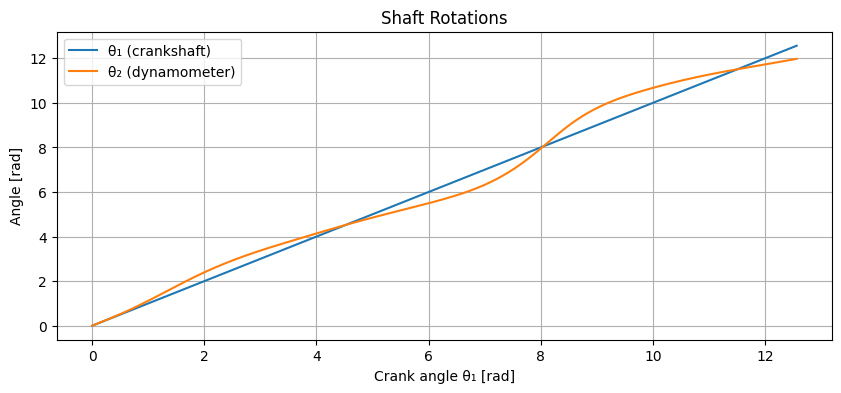

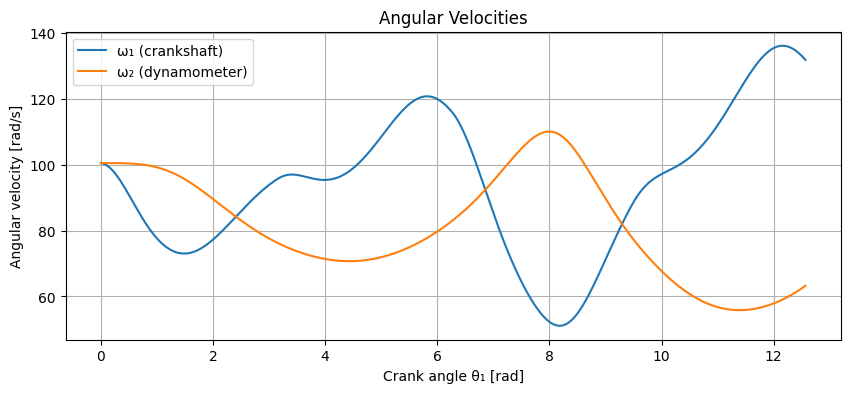

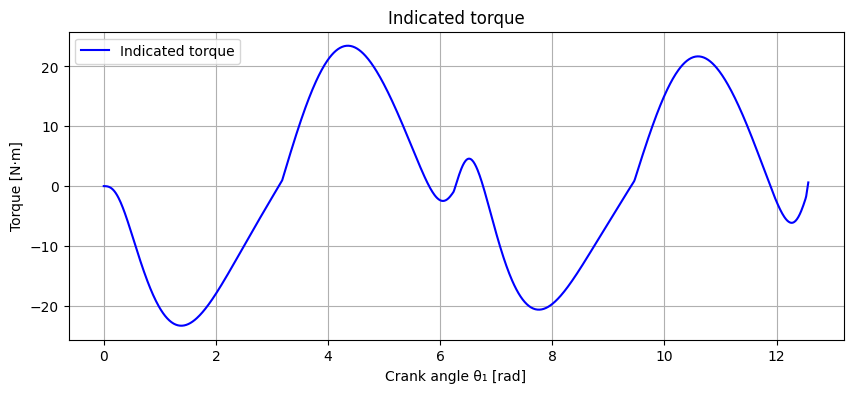

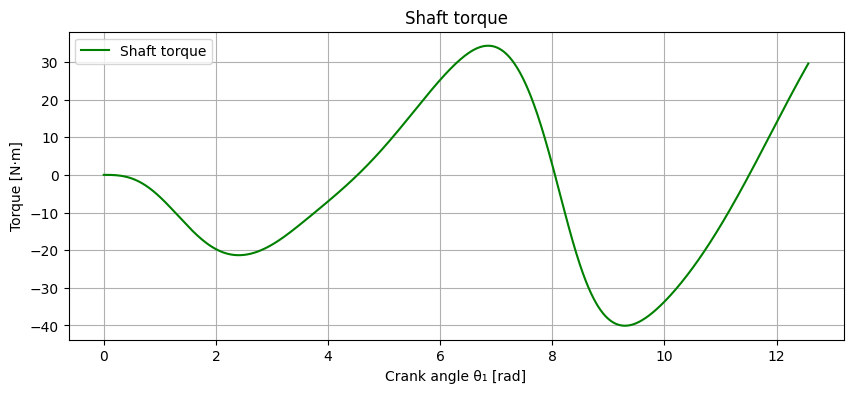

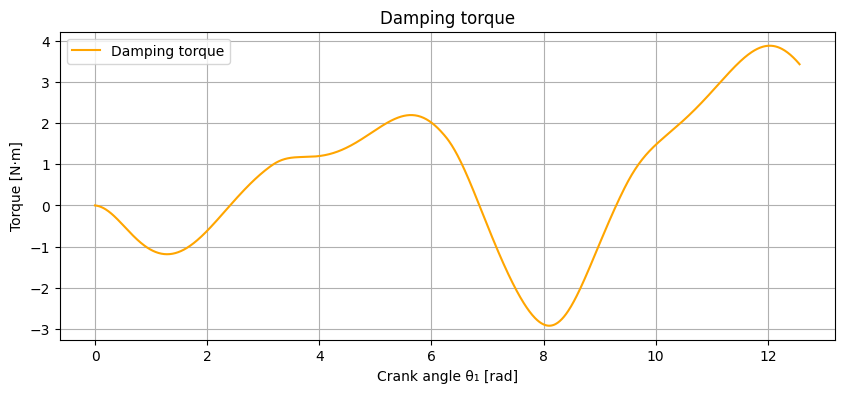

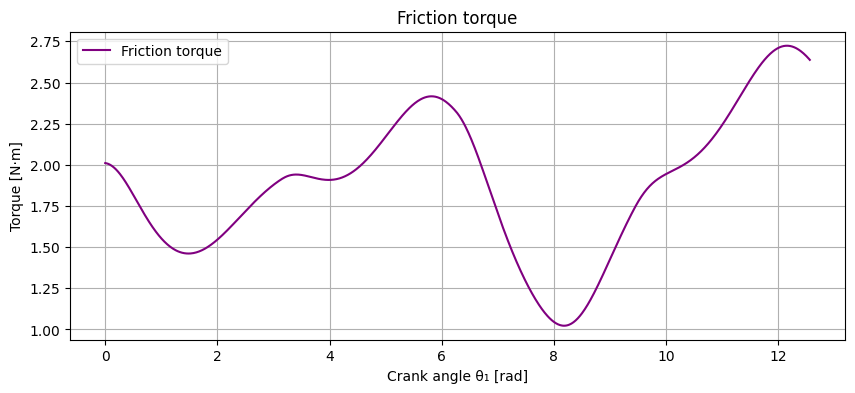

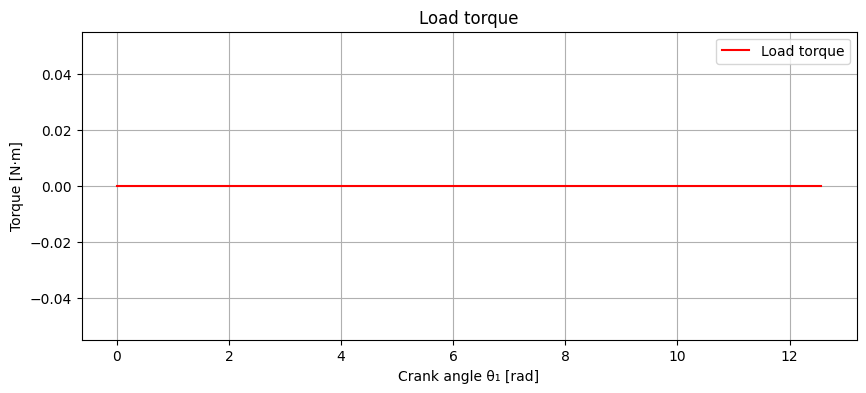

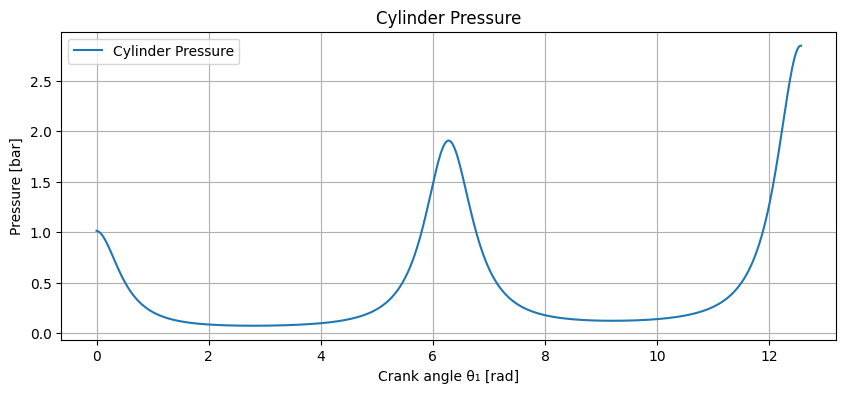

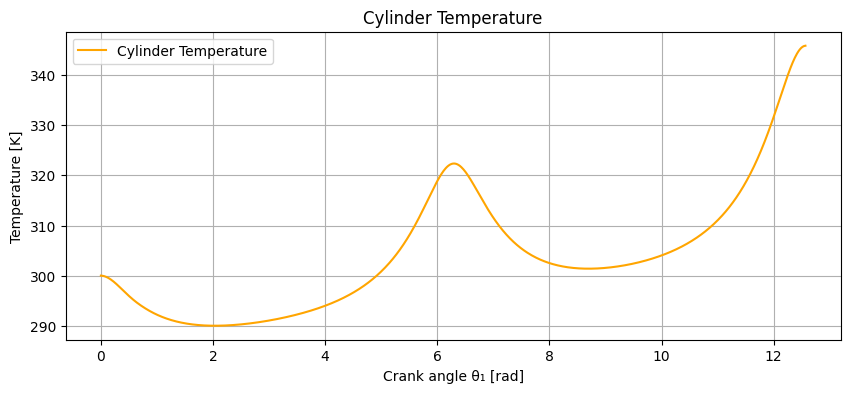

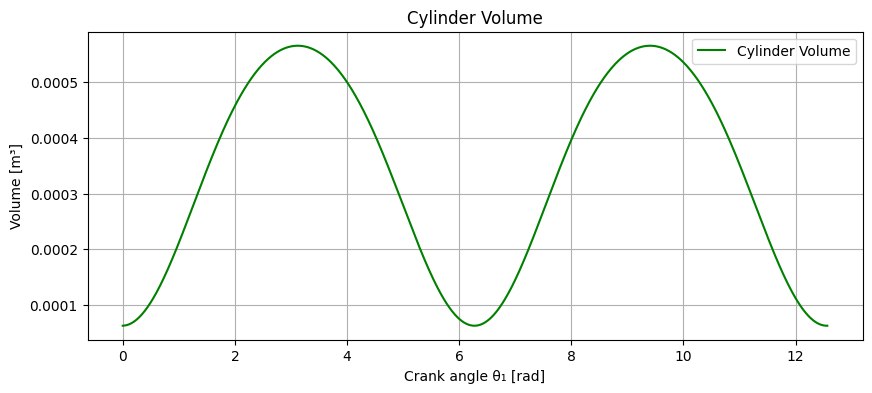

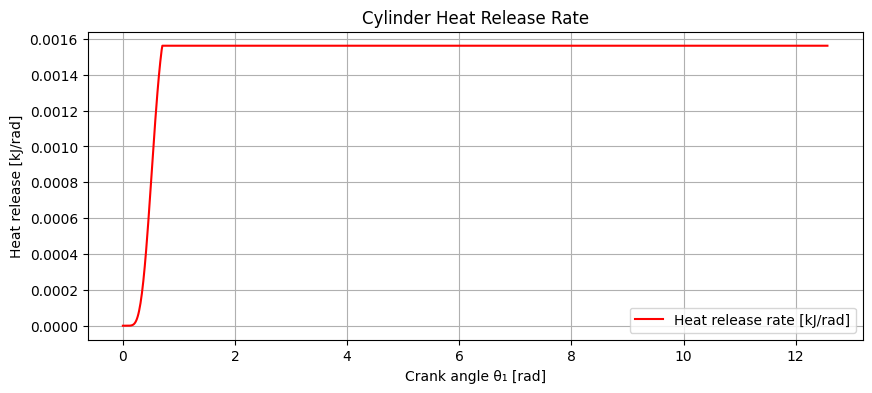

In [71]:
##############################################################################################################
# Derived quantities and plotting (fully separated)
##############################################################################################################

# --- Extract solution ---
theta1_array = theta1_eval
omega1_array = sol.y[0]
omega2_array = sol.y[1]
theta2_array = sol.y[2]
P_array      = sol.y[3]
T_array      = sol.y[4]

# Angular accelerations
domega1 = np.gradient(omega1_array, theta1_array)
domega2 = np.gradient(omega2_array, theta1_array)

# Cylinder volume
V_cyl = cylinder_volume(theta1_array, params['V_d'], params['c'], params['d'],
                        params['r'], params['L'], params['delta'], params['phi'])

# Combustion heat release rate [J/rad]
Q_comb_array = np.array([combustion_heat_release(theta, P, T, params)
                         for theta, P, T in zip(theta1_array, P_array, T_array)])

# Shaft torques
T_i_array = np.array([T_i(P, params['P_atm'], params['A_p'], params['r'], 
                          G(theta, params['r'], params['L'], params['delta'], params['phi']))
                      for theta, P in zip(theta1_array, P_array)])
T_S_array = params['S'] * (theta1_array - theta2_array)
T_D_array = params['D'] * (omega1_array - omega2_array)
T_friction_array = 0.02 * omega1_array  # simple linear friction
T_load_array = np.full_like(theta1_array, params.get('dynamo_load_torque', 0.0))


##############################################################################################################
# 1. Shaft rotations
plt.figure(figsize=(10,4))
plt.plot(theta1_array, theta1_array, label='θ₁ (crankshaft)')
plt.plot(theta1_array, theta2_array, label='θ₂ (dynamometer)')
plt.xlabel('Crank angle θ₁ [rad]')
plt.ylabel('Angle [rad]')
plt.title('Shaft Rotations')
plt.grid(True)
plt.legend()

##############################################################################################################
# 2. Angular velocities
plt.figure(figsize=(10,4))
plt.plot(theta1_array, omega1_array, label='ω₁ (crankshaft)')
plt.plot(theta1_array, omega2_array, label='ω₂ (dynamometer)')
plt.xlabel('Crank angle θ₁ [rad]')
plt.ylabel('Angular velocity [rad/s]')
plt.title('Angular Velocities')
plt.grid(True)
plt.legend()

##############################################################################################################
# 3. Torques (separate plots)
torque_names = ['Indicated torque', 'Shaft torque', 'Damping torque', 'Friction torque', 'Load torque']
torque_arrays = [T_i_array, T_S_array, T_D_array, T_friction_array, T_load_array]
colors = ['blue', 'green', 'orange', 'purple', 'red']

for name, T_arr, color in zip(torque_names, torque_arrays, colors):
    plt.figure(figsize=(10,4))
    plt.plot(theta1_array, T_arr, label=name, color=color)
    plt.xlabel('Crank angle θ₁ [rad]')
    plt.ylabel('Torque [N·m]')
    plt.title(name)
    plt.grid(True)
    plt.legend()

##############################################################################################################
# 4. Cylinder pressure
plt.figure(figsize=(10,4))
plt.plot(theta1_array, P_array / 1e5, label='Cylinder Pressure')
plt.xlabel('Crank angle θ₁ [rad]')
plt.ylabel('Pressure [bar]')
plt.title('Cylinder Pressure')
plt.grid(True)
plt.legend()

##############################################################################################################
# 5. Cylinder temperature
plt.figure(figsize=(10,4))
plt.plot(theta1_array, T_array, label='Cylinder Temperature', color='orange')
plt.xlabel('Crank angle θ₁ [rad]')
plt.ylabel('Temperature [K]')
plt.title('Cylinder Temperature')
plt.grid(True)
plt.legend()

##############################################################################################################
# 6. Cylinder volume
plt.figure(figsize=(10,4))
plt.plot(theta1_array, V_cyl, label='Cylinder Volume', color='green')
plt.xlabel('Crank angle θ₁ [rad]')
plt.ylabel('Volume [m³]')
plt.title('Cylinder Volume')
plt.grid(True)
plt.legend()

##############################################################################################################
# 7. Combustion heat release rate
plt.figure(figsize=(10,4))
plt.plot(theta1_array, Q_comb_array / 1e3, label='Heat release rate [kJ/rad]', color='red')
plt.xlabel('Crank angle θ₁ [rad]')
plt.ylabel('Heat release [kJ/rad]')
plt.title('Cylinder Heat Release Rate')
plt.grid(True)
plt.legend()

plt.show()

.

.

.

## References

[1] <a id="zweiri2001"></a>
   Zweiri, Y. H., J. F. Whidborne, and L. D. Seneviratne. "Detailed analytical model of a single-cylinder diesel engine in the crank angle
   domain." Proceedings of the Institution of Mechanical Engineers, Part D: Journal of Automobile Engineering 215.11 (2001): 1197-1216.